![image.png](https://i.imgur.com/a3uAqnb.png)

# 📝 Arabic Sentiment Analysis
An Arabic dataset is created from Arabic Saudi tweets and is manully labelled according to the polarity that each tweet conveys (positive 1, negative 0). To understand the effect of social events and political reforms on Arabic societies, polarizing developments and policies associated with Saudi Arabia’s 2030 vision are targeted in this dataset. The established vision aims to enhance the overall development of Saudi Arabia in many sectors such as economical, educational, health, tourism, etc. These events include allowing women to drive, suspending the duties of religious police, opening cinema theatres (previously banned), allowing women to enter football stadiums to watch football matches (previously restricted to male access only), etc. Arabic tweets discussing these polarizing events along with other controversial issues were targeted and collected from Twitter using Twitter’s API. The data collection phase spanned over a period of two months during the months of October and November 2018.
Stats:
2,436 Positive Tweets
1,816 Negative Tweets

(SS2030)](https://www.kaggle.com/datasets/snalyami3/arabic-sentiment-analysis-dataset-ss2030-dataset).

##  Import Required Libraries


In [ ]:
!pip install emoji
!pip install Arabic-Stopwords
!pip install wordcloud arabic-reshaper python-bidi
!pip install Tashaphyne
!pip install PyArabic

In [91]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load the Dataset


In [82]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snalyami3/arabic-sentiment-analysis-dataset-ss2030-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'arabic-sentiment-analysis-dataset-ss2030-dataset' dataset.
Path to dataset files: /kaggle/input/arabic-sentiment-analysis-dataset-ss2030-dataset


In [83]:
import kagglehub

# Download latest version
f_path = kagglehub.dataset_download("hammaadali/arial-font")

s_path = kagglehub.dataset_download("amjadkhatabi/arabic-dialects-extended-stopwords-list-sada")
print("Path to dataset files:", f_path)
print("Path to dataset files:", s_path)

Using Colab cache for faster access to the 'arial-font' dataset.
Path to dataset files: /kaggle/input/arial-font
Path to dataset files: /root/.cache/kagglehub/datasets/amjadkhatabi/arabic-dialects-extended-stopwords-list-sada/versions/1


In [84]:
FONT_PATH = f_path+'/arial.ttf'

In [85]:
STIPWORD_PATH = s_path+'/arabic_dialects_stopwords.csv'

In [92]:
arabic_stopwords = stopwords.words("arabic")
len(arabic_stopwords)

754

In [93]:
stopwords = pd.read_csv(STIPWORD_PATH)["word"].tolist()
stopwords = [arabic_reshaper.reshape(s) for s in stopwords]
print(len(stopwords))

1997


## Exploratory Data Analysis (EDA)
***Hint***
* Disply sample of the dataset
* Check for missing and duplicated values
* Explore average text length per emotion class ....


In [94]:
df = pd.read_csv(path + "/Arabic Sentiment Analysis Dataset - SS2030.csv")
df.head()

,text,Sentiment
0,حقوق المرأة 💚💚💚 https://t.co/Mzf90Ta5g1,1
1,RT @___IHAVENOIDEA: حقوق المرأة في الإسلام. ht...,1
2,RT @saud_talep: Retweeted لجنة التنمية بشبرا (...,1
3,RT @MojKsa: حقوق المرأة التي تضمنها لها وزارة ...,1
4,RT @abm112211: ولي امر الزوجة او ولي الزوجة او...,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       4252 non-null   object
 1   Sentiment  4252 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 66.6+ KB


In [97]:
df.rename(columns={'Sentiment':'label'}, inplace=True)
df.head()

,text,label
0,حقوق المرأة 💚💚💚 https://t.co/Mzf90Ta5g1,1
1,RT @___IHAVENOIDEA: حقوق المرأة في الإسلام. ht...,1
2,RT @saud_talep: Retweeted لجنة التنمية بشبرا (...,1
3,RT @MojKsa: حقوق المرأة التي تضمنها لها وزارة ...,1
4,RT @abm112211: ولي امر الزوجة او ولي الزوجة او...,1


In [10]:
print(f'Data shape: {df.shape}')

Data shape: (4252, 2)


In [11]:
df['text'].isna().sum()

np.int64(0)

In [12]:
df.duplicated().sum()

np.int64(38)

In [13]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [14]:
df.label.value_counts()

,count
label,
1,2414
0,1800


In [95]:
label_mapping = { 0: "negative ", 1: "positive"}

In [98]:
df["Sentiment"] = df["label"].map(label_mapping)
df.head()

,text,label,Sentiment
0,حقوق المرأة 💚💚💚 https://t.co/Mzf90Ta5g1,1,positive
1,RT @___IHAVENOIDEA: حقوق المرأة في الإسلام. ht...,1,positive
2,RT @saud_talep: Retweeted لجنة التنمية بشبرا (...,1,positive
3,RT @MojKsa: حقوق المرأة التي تضمنها لها وزارة ...,1,positive
4,RT @abm112211: ولي امر الزوجة او ولي الزوجة او...,1,positive


In [17]:
px.bar(df['Sentiment'].value_counts(ascending=True),template='gridon')

In [18]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
avg_length = df.groupby("Sentiment")["text_length"].mean().reset_index()
avg_length

,Sentiment,text_length
0,negative,25.146111
1,positive,21.676471


In [19]:
def column_to_wordcloud(df, column, font_file, stopwords):

    text = " ".join(arabic_reshaper.reshape(t) for t in df[column].dropna())
    # create and display the wordcloud
    wordcloud = WordCloud(font_path=font_file,width=800, height=400, max_words=200, random_state=1, background_color='white', colormap='Set2', collocations=False,
                      stopwords = stopwords).generate(text)
    plt.figure(figsize=(15,7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Most Frequent Words in the Dataset", fontsize=20)
    plt.show()

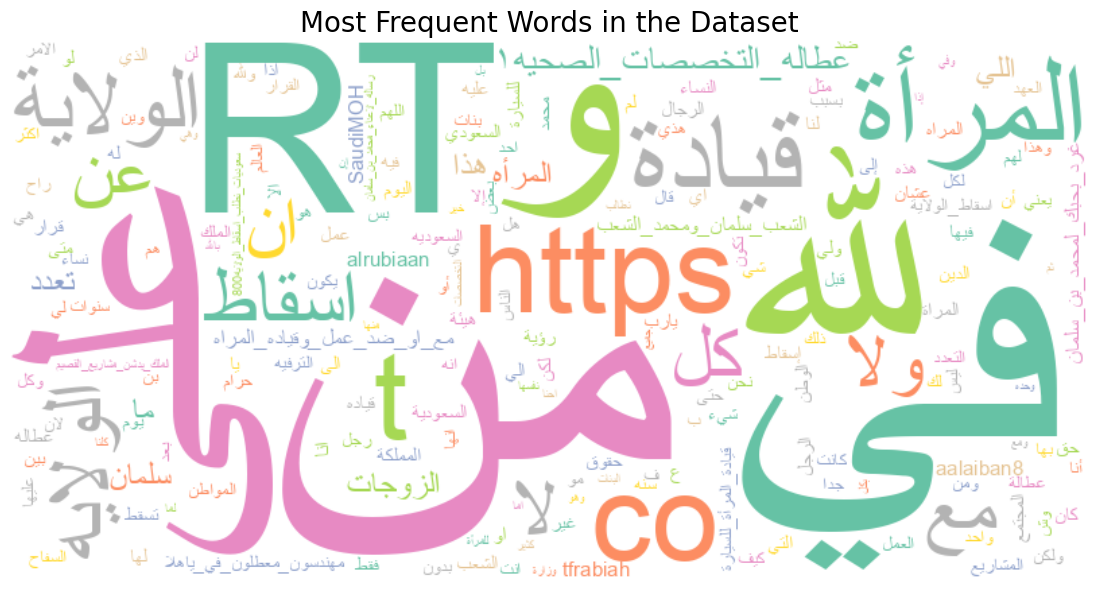

In [25]:
column_to_wordcloud(df,"text",FONT_PATH,arabic_stopwords)

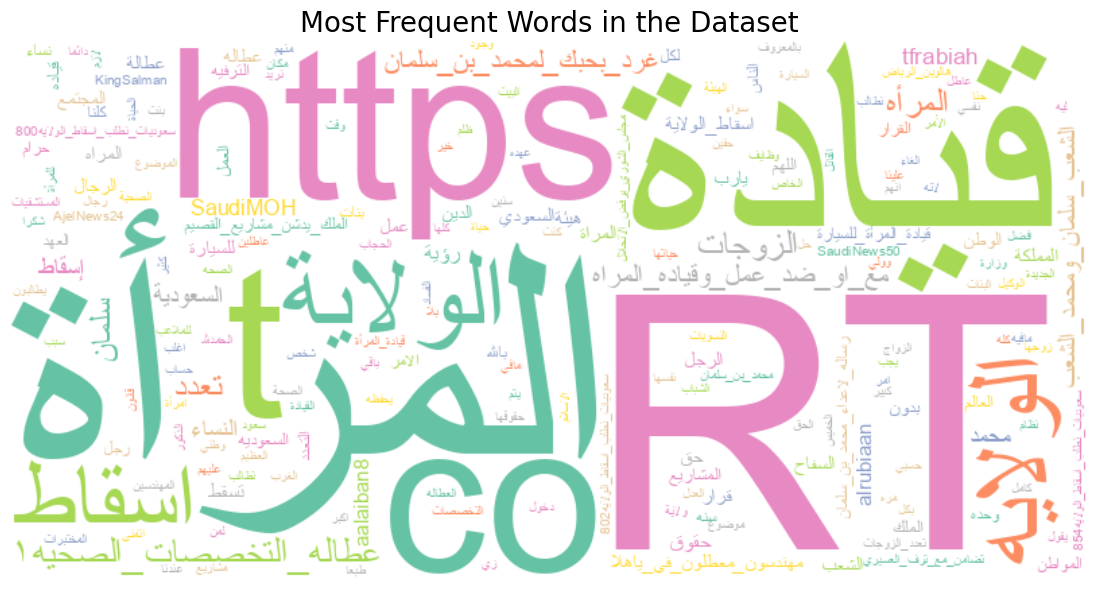

In [27]:
column_to_wordcloud(df,"text",FONT_PATH,stopwords)

##  Data Preprocessing
***Hint***
* Convert text to lowercase
* Remove punctuation, numbers, stopwords
* Tokenize and lemmatize words ...
* Transform text into numerical features (TF-IDF)


In [121]:
import re
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import emoji
from nltk.stem.isri import ISRIStemmer
from tashaphyne.stemming import ArabicLightStemmer
import pyarabic.araby as araby
import numpy as np
import regex

nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [139]:
def remove_stop_words(text):
    Text=[i for i in str(text).split() if i not in arabic_stopwords]
    return " ".join(Text)
df['clean_text'] = df['text'].apply(remove_stop_words)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق المرأة 💚💚💚 https://t.co/Mzf90Ta5g1,1,positive
1,RT @___IHAVENOIDEA: حقوق المرأة الإسلام. https...,1,positive
2,RT @saud_talep: Retweeted لجنة التنمية بشبرا (...,1,positive
3,RT @MojKsa: حقوق المرأة تضمنها وزارة العدل htt...,1,positive
4,RT @abm112211: ولي امر الزوجة او ولي الزوجة او...,1,positive


In [140]:
def ISRI_Stemmer(text):
    #making an object
    stemmer = ISRIStemmer()

    #stemming each word
    text = stemmer.stem(text)
    text = stemmer.pre32(text)
    text = stemmer.suf32(text)

    return text

df['clean_text'] = df['clean_text'].apply(ISRI_Stemmer)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق المرأة 💚💚💚 https://t.co/Mzf90Ta5g1,1,positive
1,RT @___IHAVENOIDEA: حقوق المرأة الإسلام. https...,1,positive
2,RT @saud_talep: Retweeted لجنة التنمية بشبرا (...,1,positive
3,RT @MojKsa: حقوق المرأة تضمنها وزارة العدل htt...,1,positive
4,RT @abm112211: ولي امر الزوجة او ولي الزوجة او...,1,positive


In [141]:
def Arabic_Light_Stemmer(text):
    #making an object
    Arabic_Stemmer = ArabicLightStemmer()

    #stemming each word
    text=[Arabic_Stemmer.light_stem(y) for y in text.split()]

    return " " .join(text)

df['clean_text'] = df['clean_text'].apply(Arabic_Light_Stemmer)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرأ 💚💚💚 https://t.co/Mzf90Ta5g1,1,positive
1,RT @___IHAVENOIDEA: حقوق مرأ إسلام. https://t....,1,positive
2,RT @saud_talep: Retweeted جن تنم شبرا (@Shubra...,1,positive
3,RT @MojKsa: حقوق مرأ ضم زار عدل https://t.co/Q...,1,positive
4,RT @abm112211: لي مر زوج او لي زوج او لي مرا ا...,1,positive


In [142]:
def normalizeArabic(text):
    text = text.strip()
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)

    #remove repetetions
    text = re.sub("[إأٱآا]", "ا", text)
    text = text.replace('وو', 'و')
    text = text.replace('يي', 'ي')
    text = text.replace('ييي', 'ي')
    text = text.replace('اا', 'ا')

    ## remove extra whitespace
    text = re.sub('\s+', ' ', text)

    # Remove longation
    text = re.sub(r'(.)\1+', r"\1\1", text)

    #Strip vowels from a text, include Shadda.
    text = araby.strip_tashkeel(text)

    #Strip diacritics from a text, include harakats and small lettres The striped marks are
    text = araby.strip_diacritics(text)
    text=''.join([i for i in text if not i.isdigit()])
    return text

df['clean_text'] = df['clean_text'].apply(normalizeArabic)
df[['clean_text','label','Sentiment']].head()

<>:16: SyntaxWarning:

invalid escape sequence '\s'

<>:16: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipython-input-682578153.py:16: SyntaxWarning:

invalid escape sequence '\s'



,clean_text,label,Sentiment
0,حقوق مرا 💚💚 https://t.co/MzfTag,1,positive
1,RT @__IHAVENOIDEA: حقوق مرا اسلام. https://t.c...,1,positive
2,RT @saud_talep: Retweeted جن تنم شبرا (@Shubra...,1,positive
3,RT @MojKsa: حقوق مرا ضم زار عدل https://t.co/Q...,1,positive
4,RT @abm: لي مر زوج او لي زوج او لي مرا اخطاء ش...,1,positive


In [143]:
def Removing_non_arabic(text):
    text = re.sub('[A-Za-z]+',' ',text)
    return text

df['clean_text'] = df['clean_text'].apply(Removing_non_arabic)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا 💚💚 :// . /,1,positive
1,@__ : حقوق مرا اسلام. :// . /,1,positive
2,@ _ : جن تنم شبرا (@ ): زال تسجيل مستمر دو...,1,positive
3,@ : حقوق مرا ضم زار عدل :// . /,1,positive
4,@ : لي مر زوج او لي زوج او لي مرا اخطاء شاءع...,1,positive


In [144]:
def Removing_numbers(text):
    text=''.join([i for i in text if not i.isdigit()])
    return text

df['clean_text'] = df['clean_text'].apply(Removing_numbers)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا 💚💚 :// . /,1,positive
1,@__ : حقوق مرا اسلام. :// . /,1,positive
2,@ _ : جن تنم شبرا (@ ): زال تسجيل مستمر دو...,1,positive
3,@ : حقوق مرا ضم زار عدل :// . /,1,positive
4,@ : لي مر زوج او لي زوج او لي مرا اخطاء شاءع...,1,positive


In [145]:
def Removing_punctuations(text):
    ## Remove punctuations
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
    text = text.replace('؛',"", )

    ## remove extra whitespace
    text = re.sub('\s+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()

df['clean_text'] = df['clean_text'].apply(Removing_punctuations)
df[['clean_text','label','Sentiment']].head()

<>:3: SyntaxWarning:

invalid escape sequence '\]'

<>:7: SyntaxWarning:

invalid escape sequence '\s'

<>:3: SyntaxWarning:

invalid escape sequence '\]'

<>:7: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipython-input-1579395868.py:3: SyntaxWarning:

invalid escape sequence '\]'

/tmp/ipython-input-1579395868.py:7: SyntaxWarning:

invalid escape sequence '\s'



,clean_text,label,Sentiment
0,حقوق مرا 💚💚,1,positive
1,حقوق مرا اسلام,1,positive
2,جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...,1,positive
3,حقوق مرا ضم زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...,1,positive


In [146]:
def Removing_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

df['clean_text'] = df['clean_text'].apply(Removing_urls)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا 💚💚,1,positive
1,حقوق مرا اسلام,1,positive
2,جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...,1,positive
3,حقوق مرا ضم زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...,1,positive


In [147]:
def remove_extra_Space(text):
    ## remove extra whitespace
    text = re.sub('\s+', ' ', text)
    return  " ".join(text.split())

df['clean_text'] = df['clean_text'].apply(remove_extra_Space)
df[['clean_text','label','Sentiment']].head()

<>:3: SyntaxWarning:

invalid escape sequence '\s'

<>:3: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipython-input-3727458976.py:3: SyntaxWarning:

invalid escape sequence '\s'



,clean_text,label,Sentiment
0,حقوق مرا 💚💚,1,positive
1,حقوق مرا اسلام,1,positive
2,جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...,1,positive
3,حقوق مرا ضم زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...,1,positive


In [148]:
def remove_hashtages_and_mentions(text):
    text = re.sub("@[A-Za-z0-9_]+","", text)
    text = re.sub("#[A-Za-z0-9_]+","", text)
    return text

df['clean_text'] = df['clean_text'].apply(remove_hashtages_and_mentions)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا 💚💚,1,positive
1,حقوق مرا اسلام,1,positive
2,جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...,1,positive
3,حقوق مرا ضم زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...,1,positive


In [49]:
# def demojize_text(text):
#     return emoji.demojize(text)

# df['clean_text'] = df['clean_text'].apply(demojize_text)
# df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا :green_heart::green_heart:,1,positive
1,حقوق مرا في اسلام,1,positive
2,جن تنم شبرا ما زال تسجيل مستمر في دور حقوق مرا...,1,positive
3,حقوق مرا التي ضم لها زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا من اخطاء شاءع هذ...,1,positive


In [107]:
# def remove_emoji(string):

#     emoji_pattern = re.compile("["
#                            u"\U0001F600-\U0001F64F"  # emoticons
#                            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
#                            u"\U0001F680-\U0001F6FF"  # transport & map symbols
#                            u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
#                            u"\U00002702-\U000027B0"
#                            u"\U000024C2-\U0001F251"
#                            "]+", flags=re.UNICODE)
#     return emoji_pattern.sub(r'', string).strip()

# df['clean_text'] = df['clean_text'].apply(remove_emoji)
# df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا,1,positive
1,حقوق مرا اسلام,1,positive
2,جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...,1,positive
3,حقوق مرا ضم زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...,1,positive


In [149]:
emojis_map = {
    "🙂":"يبتسم",
    "😂":"يضحك",
    "💔":"قلب حزين",
    "🙂":"يبتسم",
    "❤️":"حب",
    "❤":"حب",
    "😍":"حب",
    "😭":"يبكي",
    "😢":"حزن",
    "😔":"حزن",
    "♥":"حب",
    "💜":"حب",
    "😅":"يضحك",
    "🙁":"حزين",
    "💕":"حب",
    "💙":"حب",
    "😞":"حزين",
    "😊":"سعادة",
    "👏":"يصفق",
    "👌":"احسنت",
    "😴":"ينام",
    "😀":"يضحك",
    "😌":"حزين",
    "🌹":"وردة",
    "🙈":"حب",
    "😄":"يضحك",
    "😐":"محايد",
    "✌":"منتصر",
    "✨":"نجمه",
    "🤔":"تفكير",
    "😏":"يستهزء",
    "😒":"يستهزء",
    "🙄":"ملل",
    "😕":"عصبية",
    "😃":"يضحك",
    "🌸":"وردة",
    "😓":"حزن",
    "💞":"حب",
    "💗":"حب",
    "😑":"منزعج",
    "💭":"تفكير",
    "😎":"ثقة",
    "💛":"حب",
    "😩":"حزين",
    "💪":"عضلات",
    "👍":"موافق",
    "🙏🏻":"رجاء طلب",
    "😳":"مصدوم",
    "👏🏼":"تصفيق",
    "🎶":"موسيقي",
    "🌚":"صمت",
    "💚":"حب",
    "🙏":"رجاء طلب",
    "💘":"حب",
    "🍃":"سلام",
    "☺":"يضحك",
    "🐸":"ضفدع",
    "😶":"مصدوم",
    "✌️":"مرح",
    "✋🏻":"توقف",
    "😉":"غمزة",
    "🌷":"حب",
    "🙃":"مبتسم",
    "😫":"حزين",
    "😨":"مصدوم",
    "🎼 ":"موسيقي",
    "🍁":"مرح",
    "🍂":"مرح",
    "💟":"حب",
    "😪":"حزن",
    "😆":"يضحك",
    "😣":"استياء",
    "☺️":"حب",
    "😱":"كارثة",
    "😁":"يضحك",
    "😖":"استياء",
    "🏃🏼":"يجري",
    "😡":"غضب",
    "🚶":"يسير",
    "🤕":"مرض",
    "‼️":"تعجب",
    "🕊":"طائر",
    "👌🏻":"احسنت",
    "❣":"حب",
    "🙊":"مصدوم",
    "💃":"سعادة مرح",
    "💃🏼":"سعادة مرح",
    "😜":"مرح",
    "👊":"ضربة",
    "😟":"استياء",
    "💖":"حب",
    "😥":"حزن",
    "🎻":"موسيقي",
    "✒":"يكتب",
    "🚶🏻":"يسير",
    "💎":"الماظ",
    "😷":"وباء مرض",
    "☝":"واحد",
    "🚬":"تدخين",
    "💐" : "ورد",
    "🌞" : "شمس",
    "👆" : "الاول",
    "⚠️" :"تحذير",
    "🤗" : "احتواء",
    "✖️": "غلط",
    "📍"  : "مكان",
    "👸" : "ملكه",
    "👑" : "تاج",
    "✔️" : "صح",
    "💌": "قلب",
    "😲" : "مندهش",
    "💦": "ماء",
    "🚫" : "خطا",
    "👏🏻" : "برافو",
    "🏊" :"يسبح",
    "👍🏻": "تمام",
    "⭕️" :"دائره كبيره",
    "🎷" : "ساكسفون",
    "👋": "تلويح باليد",
    "✌🏼": "علامه النصر",
    "🌝":"مبتسم",
    "➿"  : "عقده مزدوجه",
    "💪🏼" : "قوي",
    "📩":  "تواصل معي",
    "☕️": "قهوه",
    "😧" : "قلق و صدمة",
    "🗨": "رسالة",
    "❗️" :"تعجب",
    "🙆🏻": "اشاره موافقه",
    "👯" :"اخوات",
    "©" :  "رمز",
    "👵🏽" :"سيده عجوزه",
    "🐣": "كتكوت",
    "🙌": "تشجيع",
    "🙇": "شخص ينحني",
    "👐🏽":"ايدي مفتوحه",
    "👌🏽": "بالظبط",
    "⁉️" : "استنكار",
    "⚽️": "كوره",
    "🕶" :"حب",
    "🎈" :"بالون",
    "🎀":    "ورده",
    "💵":  "فلوس",
    "😋":  "جائع",
    "😛":  "يغيظ",
    "😠":  "غاضب",
    "✍🏻":  "يكتب",
    "🌾":  "ارز",
    "👣":  "اثر قدمين",
    "❌":"رفض",
    "🍟":"طعام",
    "👬":"صداقة",
    "🐰":"ارنب",
    "☂":"مطر",
    "⚜":"مملكة فرنسا",
    "🐑":"خروف",
    "🗣":"صوت مرتفع",
    "👌🏼":"احسنت",
    "☘":"مرح",
    "😮":"صدمة",
    "😦":"قلق",
    "⭕":"الحق",
    "✏️":"قلم",
    "ℹ":"معلومات",
    "🙍🏻":"رفض",
    "⚪️":"نضارة نقاء",
    "🐤":"حزن",
    "💫":"مرح",
    "💝":"حب",
    "🍔":"طعام",
    "❤︎":"حب",
    "✈️":"سفر",
    "🏃🏻‍♀️":"يسير",
    "🍳":"ذكر",
    "🎤":"مايك غناء",
    "🎾":"كره",
    "🐔":"دجاجة",
    "🙋":"سؤال",
    "📮":"بحر",
    "💉":"دواء",
    "🙏🏼":"رجاء طلب",
    "💂🏿 ":"حارس",
    "🎬":"سينما",
    "♦️":"مرح",
    "💡":"قكرة",
    "‼":"تعجب",
    "👼":"طفل",
    "🔑":"مفتاح",
    "♥️":"حب",
    "🕋":"كعبة",
    "🐓":"دجاجة",
    "💩":"معترض",
    "👽":"فضائي",
    "☔️":"مطر",
    "🍷":"عصير",
    "🌟":"نجمة",
    "☁️":"سحب",
    "👃":"معترض",
    "🌺":"مرح",
    "🔪":"سكينة",
    "♨":"سخونية",
    "👊🏼":"ضرب",
    "✏":"قلم",
    "🚶🏾‍♀️":"يسير",
    "👊":"ضربة",
    "◾️":"وقف",
    "😚":"حب",
    "🔸":"مرح",
    "👎🏻":"لا يعجبني",
    "👊🏽":"ضربة",
    "😙":"حب",
    "🎥":"تصوير",
    "👉":"جذب انتباه",
    "👏🏽":"يصفق",
    "💪🏻":"عضلات",
    "🏴":"اسود",
    "🔥":"حريق",
    "😬":"عدم الراحة",
    "👊🏿":"يضرب",
    "🌿":"ورقه شجره",
    "✋🏼":"كف ايد",
    "👐":"ايدي مفتوحه",
    "☠️":"وجه مرعب",
    "🎉":"يهنئ",
    "🔕" :"صامت",
    "😿":"وجه حزين",
    "☹️":"وجه يائس",
    "😘" :"حب",
    "😰" :"خوف و حزن",
    "🌼":"ورده",
    "💋":  "بوسه",
    "👇":"لاسفل",
    "❣️":"حب",
    "🎧":"سماعات",
    "📝":"يكتب",
    "😇":"دايخ",
    "😈":"رعب",
    "🏃":"يجري",
    "✌🏻":"علامه النصر",
    "🔫":"يضرب",
    "❗️":"تعجب",
    "👎":"غير موافق",
    "🔐":"قفل",
    "👈":"لليمين",
    "™":"رمز",
    "🚶🏽":"يتمشي",
    "😯":"متفاجأ",
    "✊":"يد مغلقه",
    "😻":"اعجاب",
    "🙉" :"قرد",
    "👧":"طفله صغيره",
    "🔴":"دائره حمراء",
    "💪🏽":"قوه",
    "💤":"ينام",
    "👀":"ينظر",
    "✍🏻":"يكتب",
    "❄️":"تلج",
    "💀":"رعب",
    "😤":"وجه عابس",
    "🖋":"قلم",
    "🎩":"كاب",
    "☕️":"قهوه",
    "😹":"ضحك",
    "💓":"حب",
    "☄️ ":"نار",
    "👻":"رعب",
    }

emoticons_to_emoji = {
    ":)" : "🙂",
    ":(" : "🙁",
    "xD" : "😆",
    ":=(": "😭",
    ":'(": "😢",
    ":'‑(": "😢",
    "XD" : "😂",
    ":D" : "🙂",
    "♬" : "موسيقي",
    "♡" : "❤",
    "☻"  : "🙂",
    }

In [150]:
def replace_emoticon_with_emojis(text):
    words = text.split()
    converted = [emoticons_to_emoji.get(word, word) for word in words]
    return " ".join(converted)

df['clean_text'] = df['clean_text'].apply(replace_emoticon_with_emojis)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا 💚💚,1,positive
1,حقوق مرا اسلام,1,positive
2,جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...,1,positive
3,حقوق مرا ضم زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...,1,positive


In [151]:
def replace_emojis_with_text(text):
    result = ""
    for char in text:
        if char in emoji.EMOJI_DATA:
            result += " " + emojis_map.get(char, char) + " "
        else:
            result += char
    return result

df['clean_text'] = df['clean_text'].apply(replace_emojis_with_text)
df[['clean_text','label','Sentiment']].head()

,clean_text,label,Sentiment
0,حقوق مرا حب حب,1,positive
1,حقوق مرا اسلام,1,positive
2,جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...,1,positive
3,حقوق مرا ضم زار عدل,1,positive
4,لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...,1,positive


In [153]:
tokenized_texts = []

for index, row in df.iterrows():
    tokenized_texts.append(word_tokenize(row['clean_text']))

df.insert(len(df.columns)-1, 'tokenized_text', tokenized_texts)

df.head()

,text,label,Sentiment,tokenized_text,clean_text
0,حقوق المرأة 💚💚💚 https://t.co/Mzf90Ta5g1,1,positive,"[حقوق, مرا, حب, حب]",حقوق مرا حب حب
1,RT @___IHAVENOIDEA: حقوق المرأة في الإسلام. ht...,1,positive,"[حقوق, مرا, اسلام]",حقوق مرا اسلام
2,RT @saud_talep: Retweeted لجنة التنمية بشبرا (...,1,positive,"[جن, تنم, شبرا, زال, تسجيل, مستمر, دور, حقوق, ...",جن تنم شبرا زال تسجيل مستمر دور حقوق مرا طلاق ...
3,RT @MojKsa: حقوق المرأة التي تضمنها لها وزارة ...,1,positive,"[حقوق, مرا, ضم, زار, عدل]",حقوق مرا ضم زار عدل
4,RT @abm112211: ولي امر الزوجة او ولي الزوجة او...,1,positive,"[لي, مر, زوج, او, لي, زوج, او, لي, مرا, اخطاء,...",لي مر زوج او لي زوج او لي مرا اخطاء شاءع كلام ...


In [155]:
# TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

## Train-Test Split


In [156]:
# split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Machine Learning Models
Train multiple models and compare results:
- Logistic Regression
- Naive Bayes
- Support Vector Machine (SVM)


In [157]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [158]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [159]:
# SVM
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

## Model Evaluation
Evaluate models with accuracy, precision, recall, F1-score, confusion matrix


In [160]:
# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

print('Logistic Regression:\n', classification_report(y_test, y_pred_lr))
print('Naive Bayes:\n', classification_report(y_test, y_pred_nb))
print('SVM:\n', classification_report(y_test, y_pred_svm))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.84      0.81      0.82       349
           1       0.87      0.89      0.88       502

    accuracy                           0.86       851
   macro avg       0.86      0.85      0.85       851
weighted avg       0.86      0.86      0.86       851

Naive Bayes:
               precision    recall  f1-score   support

           0       0.93      0.66      0.78       349
           1       0.81      0.97      0.88       502

    accuracy                           0.84       851
   macro avg       0.87      0.82      0.83       851
weighted avg       0.86      0.84      0.84       851

SVM:
               precision    recall  f1-score   support

           0       0.84      0.83      0.84       349
           1       0.89      0.89      0.89       502

    accuracy                           0.87       851
   macro avg       0.86      0.86      0.86       851
weighted avg       0.87      0.8

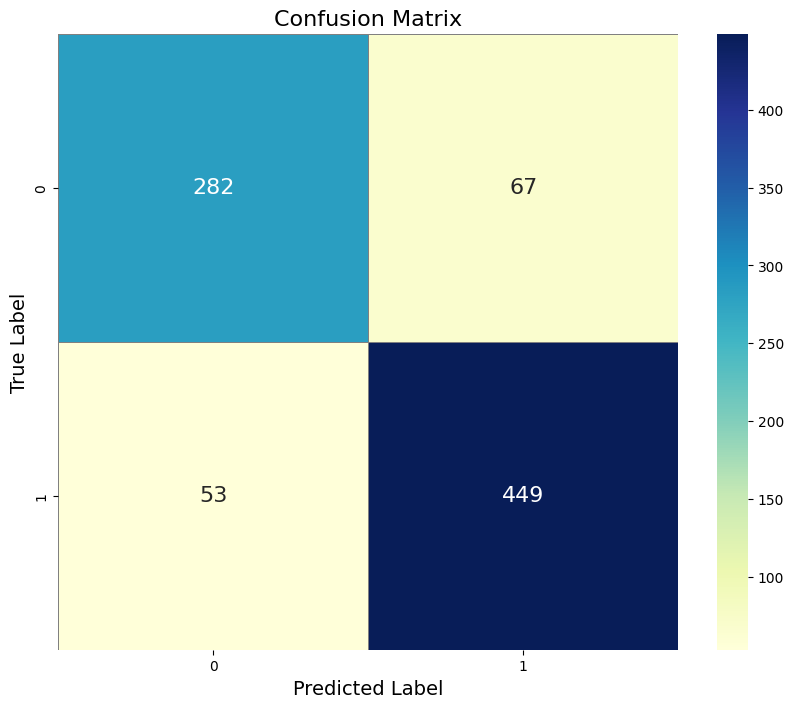

In [161]:
# Plot confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10,8))  # make figure bigger
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True, linewidths=0.5, linecolor='gray', annot_kws={"size":16})
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()